# Code to AI — Week 6, Day 1: Assignment
**Missing-Value Report — MPG Dataset**

---

**Your name:*Fatima Narejo*
**Date:**

---

## The brief

You have been handed the `mpg` dataset — fuel efficiency data for 398 cars from the 1970s
and 80s. Your job is to produce a **missing-value report** and a **cleaned copy** of the
data, and to justify every decision you make in writing.

This is the skill that matters most in real work: not just running the code, but being able
to explain why you chose what you chose.

## What to submit

Complete every task below, then push this notebook to GitHub and share the repo link in
the WhatsApp group.

## How it is marked

| Part | Marks |
|------|-------|
| Tasks 1–3: Missing-value report | 30 |
| Tasks 4–6: Cleaning the data | 40 |
| Task 7: Written justification | 20 |
| Task 8: Before/after summary | 10 |
| **Total** | **100** |

Code that runs without errors is required for full marks. Run all cells top to bottom
before you submit.

---
## Setup

In [1]:
import pandas as pd
import seaborn as sns

mpg = sns.load_dataset('mpg')
print("Shape:", mpg.shape)
mpg.head()

Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


---
## Task 1 — Explore the dataset *(10 marks)*

Print:
1. The shape of the dataset
2. The list of column names
3. The output of `.info()`

In [2]:
# Your code here
mpg.shape

(398, 9)

In [3]:
mpg.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='str')

In [4]:
mpg.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


---
## Task 2 — Missing-value report *(15 marks)*

Build a DataFrame called `report` containing, for every column:

- `missing_count` — the number of missing values
- `missing_percent` — the percentage of rows missing, rounded to 1 decimal place

Show only the columns that have at least one missing value, sorted with the worst first.

In [6]:
# Your code here
report = pd.DataFrame({
    'missing_count' : mpg.isnull().sum(),
    'missing_percent' : (mpg.isnull().mean()* 100).round(1)
})
report = report[report['missing_count'] > 0].sort_values('missing_percent', ascending=False)

report.head()


,missing_count,missing_percent
horsepower,6,1.5


---
## Task 3 — Describe what you found *(5 marks)*

In the cell below, write 2–3 sentences describing what your report shows.
Which column is affected? How serious is it?

*(Double-click this cell to edit it.)*

**Your answer:*Only horsepower column has 6 missing values out of the total 398 rows. This shows a very small portion 1.5% of the whole dataset has missing values. It is not that serious but it is important to know how to procede with that data either to drop it out or fill the values
*

---
## Task 4 — Make a safe copy *(5 marks)*

Create `clean_mpg` as a copy of `mpg`. Print the row count of both to confirm they match.

In [9]:
# Your code here
clean_mpg = mpg.copy()

print("Rows in mpg:", len(mpg))
print("Rows in clean_mpg:", len(clean_mpg))

Rows in mpg: 398
Rows in clean_mpg: 398


---
## Task 5 — Investigate before you fill *(15 marks)*

Before deciding how to handle the missing values, look at the affected column properly.

1. Print `.describe()` for the column with missing values
2. Print both its `.mean()` and its `.median()`
3. Plot a histogram of it using `.plot(kind='hist', bins=20)`

count    392.000000
mean     104.469388
std       38.491160
min       46.000000
25%       75.000000
50%       93.500000
75%      126.000000
max      230.000000
Name: horsepower, dtype: float64
Mean : 104.46938775510205
Median: 93.5


<Axes: ylabel='Frequency'>

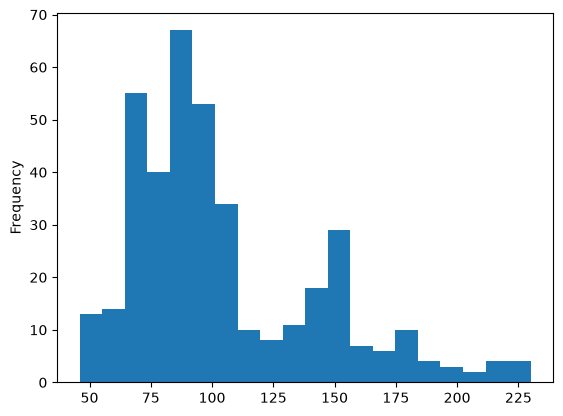

In [14]:
# Your code here
print(mpg["horsepower"].describe())

print("Mean :", mpg["horsepower"].mean())
print("Median:", mpg["horsepower"].median())

mpg["horsepower"].plot(kind='hist', bins= 20)

---
## Task 6 — Clean the data *(20 marks)*

Now handle the missing values in `clean_mpg`. You may drop the affected rows **or** fill
them — your choice, but you must justify it in Task 7.

After cleaning, print the total number of missing values remaining. It should be 0.

In [22]:
# Your code here
clean_mpg = mpg.copy()

print("Missing before:", clean_mpg['horsepower'].isnull().sum())
clean_mpg['horsepower'] = clean_mpg['horsepower'].fillna(clean_mpg['horsepower'].median())

print("Missing after: ", clean_mpg['horsepower'].isnull().sum())


Missing before: 6
Missing after:  0


---
## Task 7 — Justify your decision *(20 marks)*

This is the most important task in the assignment. Answer all three questions in the cell below.

1. **What did you do** — did you drop or fill? Which method exactly?
2. **Why** — what about the data made this the right choice? Refer to the percentage
   missing and to what you saw in Task 5.
3. **What is the downside** — what does your choice cost? Every option has a cost.
   Name it honestly.

Write at least 4–5 sentences in total. Full marks go to answers that show real thinking,
not to answers that simply repeat what the code does.

*(Double-click this cell to edit it.)*

**Your answer:**

**1. What I did:*For the mpg dataset column 'Horsepower' I filled in the missing 6 values. I filled the values with .fillna() method with the median this way all the 398 rows of the dataset are preserved.*


**2. Why:*Even though in the beginning I saw the percentage of missing value was 1.5% comparing it to the huge dataset of 398 values I thought it would be best to drop it but after I presented the data on a histogram i noticed that the column horsepower had many outliers and extrreme values than normal and mean is sensitive to those outliers, while median is more reliable for those outliers. Also, the median values will ensure the dataset does not get biased by those extreme values.

**3. The downside:*the downside is that the median will effect the accuracy and originality of the dataset because those 6 median values are not the correct results of horsepower for those rows.*

---
## Task 8 — Before and after *(10 marks)*

Print a clear summary comparing the original and the cleaned data:

- Total missing values before and after
- Number of rows before and after
- Number of columns before and after

In [23]:
# Your code here
print("Total missing values BEFORE:", mpg.isnull().sum().sum())
print("Total missing values AFTER: ", clean_mpg.isnull().sum().sum())
print()
print("Rows kept:", len(clean_mpg), "out of", len(mpg))
print("Columns:  ", len(clean_mpg.columns))




Total missing values BEFORE: 6
Total missing values AFTER:  0

Rows kept: 398 out of 398
Columns:   9


---
## Stretch task (optional, no marks)

The `horsepower` column relates to other columns in the data — heavier cars with more
cylinders generally have more horsepower.

Instead of filling with the overall median, try filling each missing value with the median
horsepower **of cars with the same number of cylinders**.

Does the result look more sensible than the plain median? Write a sentence on what you find.

In [ ]:
# Your code here (optional)



---
## Before you submit — checklist

- [ ] Every code cell runs without an error
- [ ] I clicked **Runtime → Restart and run all** and everything still works
- [ ] Task 3 and Task 7 are written in full sentences, not bullet fragments
- [ ] My name is filled in at the top
- [ ] The notebook is pushed to GitHub
- [ ] The repo link is posted in the WhatsApp group

Good luck! Ask in the group if anything is unclear. 🚀